In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

DATA_DIR = "../data"

train = pd.read_csv(f"{DATA_DIR}/train.csv", parse_dates=["date"])
test = pd.read_csv(f"{DATA_DIR}/test.csv", parse_dates=["date"])
stores = pd.read_csv(f"{DATA_DIR}/stores.csv")
oil = pd.read_csv(f"{DATA_DIR}/oil.csv", parse_dates=["date"])
holidays = pd.read_csv(f"{DATA_DIR}/holidays_events.csv", parse_dates=["date"])

print("train:", train.shape)
print("test:", test.shape)

train: (3000888, 6)
test: (28512, 5)


In [2]:
test["sales"] = np.nan  # test nie ma sales, więc dodajemy placeholder
test["is_train"] = False
train["is_train"] = True

full = pd.concat([train, test], axis=0, ignore_index=True)
full = full.sort_values(["store_nbr", "family", "date"]).reset_index(drop=True)

print("Full combined shape:", full.shape)
print(full["is_train"].value_counts())

Full combined shape: (3029400, 7)
is_train
True     3000888
False      28512
Name: count, dtype: int64


In [3]:
full["day_of_week"] = full["date"].dt.dayofweek  # 0=Monday, 6=Sunday
full["day_of_month"] = full["date"].dt.day
full["month"] = full["date"].dt.month
full["year"] = full["date"].dt.year
full["is_weekend"] = full["day_of_week"].isin([5, 6]).astype(int)

print(full[["date", "day_of_week", "day_of_month", "month", "year", "is_weekend"]].head(10))

        date  day_of_week  day_of_month  month  year  is_weekend
0 2013-01-01            1             1      1  2013           0
1 2013-01-02            2             2      1  2013           0
2 2013-01-03            3             3      1  2013           0
3 2013-01-04            4             4      1  2013           0
4 2013-01-05            5             5      1  2013           1
5 2013-01-06            6             6      1  2013           1
6 2013-01-07            0             7      1  2013           0
7 2013-01-08            1             8      1  2013           0
8 2013-01-09            2             9      1  2013           0
9 2013-01-10            3            10      1  2013           0


In [4]:
# Real non-working holidays (Holiday NOT transferred + Transfer + Additional + Bridge)
real_holidays = holidays[(holidays["type"] == "Holiday") & (holidays["transferred"] == False)]
transfer_days = holidays[holidays["type"] == "Transfer"]
additional_days = holidays[holidays["type"].isin(["Additional", "Bridge"])]

non_working_days = pd.concat([real_holidays, transfer_days, additional_days])[["date"]].drop_duplicates()
non_working_days["is_holiday"] = 1

# Work Day = normally a day off, but actually a working day (cancels out weekend/holiday effect)
work_days = holidays[holidays["type"] == "Work Day"][["date"]].drop_duplicates()
work_days["is_work_day"] = 1

full = full.merge(non_working_days, on="date", how="left")
full = full.merge(work_days, on="date", how="left")

full["is_holiday"] = full["is_holiday"].fillna(0).astype(int)
full["is_work_day"] = full["is_work_day"].fillna(0).astype(int)

# Work Day overrides is_holiday/is_weekend effect - it's a forced working day
full.loc[full["is_work_day"] == 1, "is_holiday"] = 0

print(full[["date", "is_holiday", "is_work_day"]].drop_duplicates(subset="date").query("is_holiday == 1 or is_work_day == 1").head(15))

          date  is_holiday  is_work_day
0   2013-01-01           1            0
4   2013-01-05           0            1
11  2013-01-12           0            1
41  2013-02-11           1            0
42  2013-02-12           1            0
60  2013-03-02           1            0
90  2013-04-01           1            0
101 2013-04-12           1            0
103 2013-04-14           1            0
110 2013-04-21           1            0
118 2013-04-29           1            0
120 2013-05-01           1            0
130 2013-05-11           1            0
131 2013-05-12           1            0
143 2013-05-24           1            0


In [5]:
oil_filled = oil.set_index("date").reindex(
    pd.date_range(full["date"].min(), full["date"].max(), freq="D")
)
oil_filled["dcoilwtico"] = oil_filled["dcoilwtico"].interpolate(method="linear").bfill()
oil_filled = oil_filled.reset_index().rename(columns={"index": "date", "dcoilwtico": "oil_price"})

full = full.merge(oil_filled, on="date", how="left")

print("Missing oil_price after merge:", full["oil_price"].isna().sum())
print(full[["date", "oil_price"]].head())

Missing oil_price after merge: 0
        date  oil_price
0 2013-01-01  93.140000
1 2013-01-02  93.140000
2 2013-01-03  92.970000
3 2013-01-04  93.120000
4 2013-01-05  93.146667


In [6]:
full = full.merge(stores, on="store_nbr", how="left")

print("Missing values after stores merge:")
print(full[["type", "cluster", "city", "state"]].isna().sum())
print()
print(full[["store_nbr", "city", "state", "type", "cluster"]].drop_duplicates().head())

Missing values after stores merge:
type       0
cluster    0
city       0
state      0
dtype: int64

        store_nbr           city                           state type  cluster
0               1          Quito                       Pichincha    D       13
56100           2          Quito                       Pichincha    D       13
112200          3          Quito                       Pichincha    D        8
168300          4          Quito                       Pichincha    D        9
224400          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4


In [7]:
full = full.sort_values(["store_nbr", "family", "date"]).reset_index(drop=True)

for lag in [7, 14, 28]:
    full[f"lag_{lag}"] = full.groupby(["store_nbr", "family"])["sales"].shift(lag)

print(full[["store_nbr", "family", "date", "sales", "lag_7", "lag_14", "lag_28"]].head(35).tail(15))

    store_nbr      family       date  sales  lag_7  lag_14  lag_28
20          1  AUTOMOTIVE 2013-01-21    1.0    2.0     0.0     NaN
21          1  AUTOMOTIVE 2013-01-22    1.0    1.0     2.0     NaN
22          1  AUTOMOTIVE 2013-01-23    3.0    1.0     2.0     NaN
23          1  AUTOMOTIVE 2013-01-24    0.0    1.0     2.0     NaN
24          1  AUTOMOTIVE 2013-01-25    5.0    0.0     3.0     NaN
25          1  AUTOMOTIVE 2013-01-26    4.0    5.0     2.0     NaN
26          1  AUTOMOTIVE 2013-01-27    2.0    3.0     2.0     NaN
27          1  AUTOMOTIVE 2013-01-28    3.0    1.0     2.0     NaN
28          1  AUTOMOTIVE 2013-01-29    2.0    1.0     1.0     0.0
29          1  AUTOMOTIVE 2013-01-30    6.0    3.0     1.0     2.0
30          1  AUTOMOTIVE 2013-01-31    0.0    0.0     1.0     3.0
31          1  AUTOMOTIVE 2013-02-01    3.0    5.0     0.0     3.0
32          1  AUTOMOTIVE 2013-02-02    0.0    4.0     5.0     5.0
33          1  AUTOMOTIVE 2013-02-03    0.0    2.0     3.0    

In [8]:
full["sales_shifted"] = full.groupby(["store_nbr", "family"])["sales"].shift(1)

for window in [7, 28]:
    full[f"rolling_mean_{window}"] = (
        full.groupby(["store_nbr", "family"])["sales_shifted"]
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )
    full[f"rolling_std_{window}"] = (
        full.groupby(["store_nbr", "family"])["sales_shifted"]
        .transform(lambda x: x.rolling(window, min_periods=1).std())
    )

full = full.drop(columns=["sales_shifted"])

print(full[["store_nbr", "family", "date", "sales", "rolling_mean_7", "rolling_std_7", "rolling_mean_28"]].head(35).tail(15))

    store_nbr      family       date  sales  rolling_mean_7  rolling_std_7  \
20          1  AUTOMOTIVE 2013-01-21    1.0        1.857143       1.676163   
21          1  AUTOMOTIVE 2013-01-22    1.0        1.714286       1.704336   
22          1  AUTOMOTIVE 2013-01-23    3.0        1.714286       1.704336   
23          1  AUTOMOTIVE 2013-01-24    0.0        2.000000       1.732051   
24          1  AUTOMOTIVE 2013-01-25    5.0        1.857143       1.864454   
25          1  AUTOMOTIVE 2013-01-26    4.0        2.571429       1.988060   
26          1  AUTOMOTIVE 2013-01-27    2.0        2.428571       1.812654   
27          1  AUTOMOTIVE 2013-01-28    3.0        2.285714       1.799471   
28          1  AUTOMOTIVE 2013-01-29    2.0        2.571429       1.718249   
29          1  AUTOMOTIVE 2013-01-30    6.0        2.714286       1.603567   
30          1  AUTOMOTIVE 2013-01-31    0.0        3.142857       2.035401   
31          1  AUTOMOTIVE 2013-02-01    3.0        3.142857     

In [9]:
full["sales_log"] = np.log1p(full["sales"])

print(full[["sales", "sales_log"]].describe())

              sales     sales_log
count  3.000888e+06  3.000888e+06
mean   3.577757e+02  2.926368e+00
std    1.101998e+03  2.695122e+00
min    0.000000e+00  0.000000e+00
25%    0.000000e+00  0.000000e+00
50%    1.100000e+01  2.484907e+00
75%    1.958473e+02  5.282428e+00
max    1.247170e+05  1.173381e+01


In [10]:
train_processed = full[full["is_train"] == True].copy()
test_processed = full[full["is_train"] == False].copy()

print("train_processed:", train_processed.shape)
print("test_processed:", test_processed.shape)

train_processed: (3000888, 27)
test_processed: (28512, 27)


In [11]:
train_processed.to_parquet(f"{DATA_DIR}/train_processed.parquet", index=False)
test_processed.to_parquet(f"{DATA_DIR}/test_processed.parquet", index=False)

print("Saved successfully.")

Saved successfully.


In [12]:
print(full.shape)
print(full.columns.tolist())

(3029400, 27)
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'is_train', 'day_of_week', 'day_of_month', 'month', 'year', 'is_weekend', 'is_holiday', 'is_work_day', 'oil_price', 'city', 'state', 'type', 'cluster', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_28', 'rolling_std_28', 'sales_log']


In [14]:
full = pd.concat([train, test], axis=0, ignore_index=True)
full = full.sort_values(["store_nbr", "family", "date"]).reset_index(drop=True)

In [15]:
# Add missing Dec 25 rows (stores were closed, so these dates don't exist in the raw data)
existing_combos = full[["store_nbr", "family"]].drop_duplicates()
christmas_dates = pd.to_datetime([f"{y}-12-25" for y in range(2013, 2017)])

christmas_rows = existing_combos.assign(key=1).merge(
    pd.DataFrame({"date": christmas_dates, "key": 1}), on="key"
).drop(columns="key")
christmas_rows["sales"] = 0.0
christmas_rows["onpromotion"] = 0
christmas_rows["is_train"] = True
christmas_rows["id"] = -1  # placeholder, these rows have no original Kaggle id

full = pd.concat([full, christmas_rows], axis=0, ignore_index=True)
full = full.sort_values(["store_nbr", "family", "date"]).reset_index(drop=True)

print("Shape after adding Christmas rows:", full.shape)
print(full[full["date"].dt.strftime("%m-%d") == "12-25"]["date"].dt.year.value_counts())

Shape after adding Christmas rows: (3036528, 7)
date
2013    1782
2014    1782
2015    1782
2016    1782
Name: count, dtype: int64


In [16]:
print((full["id"] == -1).sum())

7128


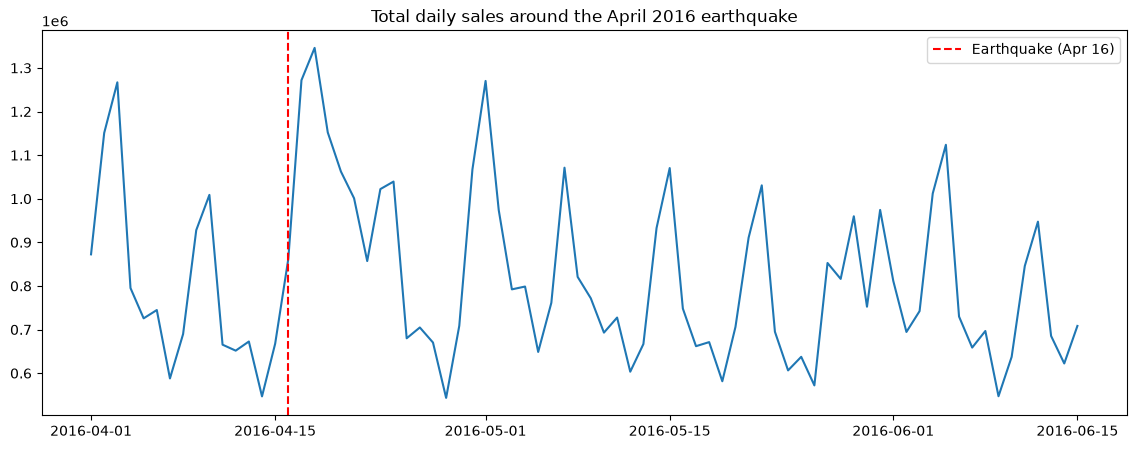

In [18]:
import matplotlib.pyplot as plt

earthquake_check = full[(full["date"] >= "2016-04-01") & (full["date"] <= "2016-06-15") & (full["is_train"] == True)]
daily_total = earthquake_check.groupby("date")["sales"].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_total.index, daily_total.values)
plt.axvline(x=pd.Timestamp("2016-04-16"), color="red", linestyle="--", label="Earthquake (Apr 16)")
plt.title("Total daily sales around the April 2016 earthquake")
plt.legend()
plt.show()

In [19]:
# Earthquake correction: replace Apr 16 - May 7 2016 sales with same-weekday average
# from the surrounding unaffected weeks (2 weeks before and 4 weeks after)
quake_start = pd.Timestamp("2016-04-16")
quake_end = pd.Timestamp("2016-05-07")

reference_mask = (
    ((full["date"] >= quake_start - pd.Timedelta(days=21)) & (full["date"] < quake_start)) |
    ((full["date"] > quake_end) & (full["date"] <= quake_end + pd.Timedelta(days=28)))
)
reference_data = full[reference_mask & full["is_train"]].copy()
reference_data["dow"] = reference_data["date"].dt.dayofweek

replacement = reference_data.groupby(["store_nbr", "family", "dow"])["sales"].mean().reset_index()
replacement = replacement.rename(columns={"sales": "sales_replacement"})

quake_mask = (full["date"] >= quake_start) & (full["date"] <= quake_end) & (full["is_train"])
full["dow"] = full["date"].dt.dayofweek
full = full.merge(replacement, on=["store_nbr", "family", "dow"], how="left")
full.loc[quake_mask, "sales"] = full.loc[quake_mask, "sales_replacement"]
full = full.drop(columns=["dow", "sales_replacement"])

print("Earthquake correction applied. Rows corrected:", quake_mask.sum())

# Now recompute calendar features, holidays, oil, stores, and lags on the corrected data
full["day_of_week"] = full["date"].dt.dayofweek
full["day_of_month"] = full["date"].dt.day
full["month"] = full["date"].dt.month
full["year"] = full["date"].dt.year
full["is_weekend"] = full["day_of_week"].isin([5, 6]).astype(int)
full["day_of_year"] = full["date"].dt.dayofyear

print("Done - ready for holiday/oil/store merges next.")

Earthquake correction applied. Rows corrected: 39204
Done - ready for holiday/oil/store merges next.


In [21]:
print([name for name in dir() if 'holiday' in name.lower() or 'oil' in name.lower() or 'store' in name.lower()])

['holidays', 'oil', 'oil_filled', 'real_holidays', 'stores']


In [22]:
real_holidays = holidays[(holidays["type"] == "Holiday") & (holidays["transferred"] == False)]
transfer_days = holidays[holidays["type"] == "Transfer"]
additional_days = holidays[holidays["type"].isin(["Additional", "Bridge"])]

non_working_days = pd.concat([real_holidays, transfer_days, additional_days])[["date"]].drop_duplicates()
non_working_days["is_holiday"] = 1

work_days = holidays[holidays["type"] == "Work Day"][["date"]].drop_duplicates()
work_days["is_work_day"] = 1

full = full.merge(non_working_days, on="date", how="left")
full = full.merge(work_days, on="date", how="left")
full["is_holiday"] = full["is_holiday"].fillna(0).astype(int)
full["is_work_day"] = full["is_work_day"].fillna(0).astype(int)
full.loc[full["is_work_day"] == 1, "is_holiday"] = 0

oil_filled = oil.set_index("date").reindex(
    pd.date_range(full["date"].min(), full["date"].max(), freq="D")
)
oil_filled["dcoilwtico"] = oil_filled["dcoilwtico"].interpolate(method="linear").bfill()
oil_filled = oil_filled.reset_index().rename(columns={"index": "date", "dcoilwtico": "oil_price"})
full = full.merge(oil_filled, on="date", how="left")

full = full.merge(stores, on="store_nbr", how="left")

print("Shape after holidays/oil/stores merge:", full.shape)
print("Missing values:", full[["is_holiday", "is_work_day", "oil_price", "type", "cluster"]].isna().sum().sum())

Shape after holidays/oil/stores merge: (3036528, 20)
Missing values: 0


In [23]:
full = full.sort_values(["store_nbr", "family", "date"]).reset_index(drop=True)

for lag in [7, 14, 28, 364]:
    full[f"lag_{lag}"] = full.groupby(["store_nbr", "family"])["sales"].shift(lag)

for window in [7, 28]:
    full[f"rolling_mean_{window}"] = (
        full.groupby(["store_nbr", "family"])["sales"]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    full[f"rolling_std_{window}"] = (
        full.groupby(["store_nbr", "family"])["sales"]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std())
    )

# Promotion relative to each series' typical promotion level (using only past data, shifted)
full["promo_typical"] = (
    full.groupby(["store_nbr", "family"])["onpromotion"]
    .transform(lambda x: x.shift(1).rolling(90, min_periods=1).mean())
)
full["promo_relative"] = full["onpromotion"] / (full["promo_typical"] + 1)

full["sales_log"] = np.log1p(full["sales"])

print("Final shape:", full.shape)
print("Columns:", full.columns.tolist())

Final shape: (3036528, 31)
Columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'is_train', 'day_of_week', 'day_of_month', 'month', 'year', 'is_weekend', 'day_of_year', 'is_holiday', 'is_work_day', 'oil_price', 'city', 'state', 'type', 'cluster', 'lag_7', 'lag_14', 'lag_28', 'lag_364', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_28', 'rolling_std_28', 'promo_typical', 'promo_relative', 'sales_log']


In [24]:
train_v3 = full[full["is_train"] == True].copy()
test_v3 = full[full["is_train"] == False].copy()

# drop the placeholder Christmas rows' id=-1 before saving train (keep the rows, just don't confuse with real ids)
train_v3.to_parquet(f"{DATA_DIR}/train_processed_v3.parquet", index=False)
test_v3.to_parquet(f"{DATA_DIR}/test_processed_v3.parquet", index=False)

print("train_v3:", train_v3.shape)
print("test_v3:", test_v3.shape)
print("Saved.")

train_v3: (3008016, 31)
test_v3: (28512, 31)
Saved.
